<a href="https://colab.research.google.com/github/vanecornejo/Procesos-Estocasticos/blob/main/Descomposici%C3%B3n%20can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descomposición Canónica**

La descomposición canónica se utiliza para el análisis de cadenas de Markov, organizando la matriz de transición en una forma estructurada que refleje el comportamiento de los estados. Mediante una simple reordenación de filas y columnas, se agrupan los estados con características similares, lo que permite distinguir claramente entre aquellos que pueden abandonarse y aquellos que forman parte del comportamiento estable del sistema.

De esta manera, vamos a analizar la matriz

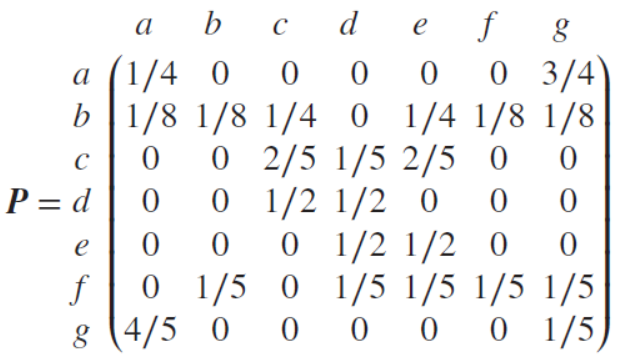

para así determinar si la matriz tiene o no distribución límite. Escribiremos la descomposición canónica de la matriz, se determinará el límite de la potencia n-esima y se va a comparar contra las distribuciones límite de las submatrices.

In [1]:
# Importamos librería necesaria

from sympy import *
import networkx as nx
import matplotlib.pyplot as plt

Hay que definir la matriz de transición $P$ de la cadena de Markov.

In [2]:
P = Matrix([
    [1/4, 0, 0, 0, 0, 0, 3/4],
    [1/8, 1/8, 1/4, 0, 1/4, 1/8, 1/8],
    [0, 0, 2/5, 1/5, 2/5, 0, 0],
    [0, 0, 1/2, 1/2, 0, 0, 0],
    [0, 0, 0, 1/2, 1/2, 0, 0],
    [0, 1/5, 0, 1/5, 1/5, 1/5, 1/5],
    [4/5, 0, 0, 0, 0, 0, 1/5]
])

P

Matrix([
[ 0.25,     0,    0,   0,    0,     0,  0.75],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2],
[  0.8,     0,    0,   0,    0,     0,   0.2]])

## Diagrama de transiciones

Hagamos el gráfico de la cadena de Markov como un grafo dirigido donde los nodos representan los estado de la cadena de Markov y los aristas las probabilidades de transición.

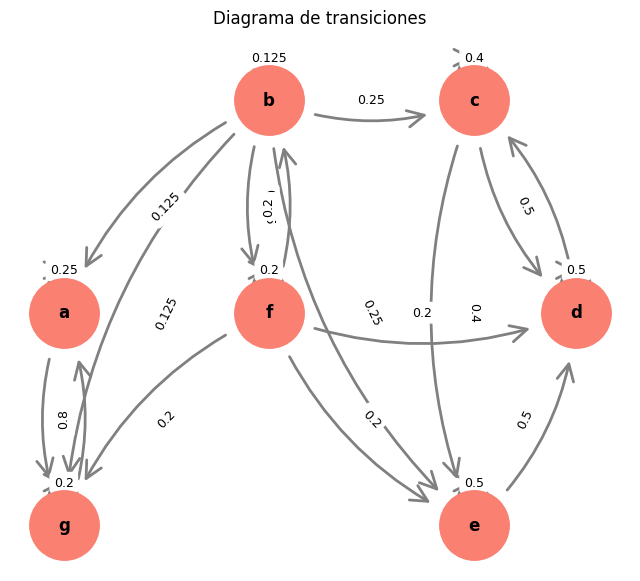

In [3]:
# Guardamos los estados de la cadena
estados = ["a", "b", "c", "d", "e", "f", "g"]

G = nx.DiGraph()
G.add_nodes_from(estados)

# Las transiciones de acuerdo a la matriz:

# a
G.add_edge("a", "a", weight=1/4)
G.add_edge("a", "g", weight=3/4)

# b
G.add_edge("b", "a", weight=1/8)
G.add_edge("b", "b", weight=1/8)
G.add_edge("b", "c", weight=1/4)
G.add_edge("b", "e", weight=1/4)
G.add_edge("b", "f", weight=1/8)
G.add_edge("b", "g", weight=1/8)

# c
G.add_edge("c", "c", weight=2/5)
G.add_edge("c", "d", weight=1/5)
G.add_edge("c", "e", weight=2/5)

# d
G.add_edge("d", "c", weight=1/2)
G.add_edge("d", "d", weight=1/2)

# e
G.add_edge("e", "d", weight=1/2)
G.add_edge("e", "e", weight=1/2)

# f
G.add_edge("f", "b", weight=1/5)
G.add_edge("f", "d", weight=1/5)
G.add_edge("f", "e", weight=1/5)
G.add_edge("f", "f", weight=1/5)
G.add_edge("f", "g", weight=1/5)

# g
G.add_edge("g", "a", weight=4/5)
G.add_edge("g", "g", weight=1/5)


# Ahora las posiciones:
posiciones = {
    "a": (-2, 0),
    "b": (0, 2),
    "c": (2, 2),
    "d": (3, 0),
    "e": (2, -2),
    "f": (0, 0),
    "g": (-2, -2)
}


# Dibujamos el grafo

plt.figure(figsize=(8,7))

nx.draw_networkx_nodes(G, posiciones, node_color="salmon", node_size=2500)  # para los nodos
nx.draw_networkx_labels(G, posiciones, font_size=12, font_weight="bold")  # para las curvas y etiquetas

# para las flechas
nx.draw_networkx_edges(
    G, posiciones,
    edge_color="grey",
    arrowstyle="->",
    arrowsize=30,
    width=2,
    min_source_margin=35,
    min_target_margin=35,
    connectionstyle="arc3,rad=0.2"
)

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=labels, font_size=9)

plt.title("Diagrama de transiciones")
plt.axis("off")
plt.show()

## Distribución límite

Una cadena tiene distribución límite si:

- Es irreducible
- Es aperiódica

También puede analizarse mediante el comportamiento de $P^n$.

In [4]:
P10 = P**10
P50 = P**50
P100 = P**100

print("\n P^10 =")
display(P10)

print("\n P^50 =")
display(P50)

print("\n P^100 =")
display(P100)


 P^10 =


Matrix([
[0.517354654010254,                   0,                 0,                 0,                 0,                   0, 0.482645345989746],
[0.171988654922658, 5.05661934518814e-6, 0.222173673923512, 0.266708044001801, 0.177778206582227, 5.05661934518814e-6, 0.161341307331112],
[                0,                   0,      0.3333117166,      0.4000406558,      0.2666476276,                   0,                 0],
[                0,                   0,      0.3333095345,      0.3999736235,       0.266716842,                   0,                 0],
[                0,                   0,      0.3333960525,       0.399988745,      0.2666152025,                   0,                 0],
[  0.1724017220618, 8.09059095230103e-6,  0.22220883367762, 0.266664125602881, 0.177782919931563, 8.09059095230103e-6, 0.160926217544232],
[0.514821702389063,                   0,                 0,                 0,                 0,                   0, 0.485178297610938]])


 P^50 =


Matrix([
[0.516129032258116,                    0,                 0,                 0,                 0,                    0, 0.483870967741886],
[0.172043010752686, 1.51075729836657e-25, 0.222222222222222, 0.266666666666667, 0.177777777777778, 1.51075729836657e-25, 0.161290322580648],
[                0,                    0, 0.333333333333333,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333333,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333334,               0.4, 0.266666666666667,                    0,                 0],
[0.172043010752703, 2.41721167738652e-25, 0.222222222222222, 0.266666666666667, 0.177777777777778, 2.41721167738652e-25, 0.161290322580631],
[0.516129032258012,                    0,                 0,                 0,                 0,                    0,  0.48387096774199]])


 P^100 =


Matrix([
[0.516129032258066,                    0,                 0,                 0,                 0,                    0, 0.483870967741937],
[0.172043010752689, 5.93420779787647e-50, 0.222222222222222, 0.266666666666667, 0.177777777777778, 5.93420779787647e-50, 0.161290322580646],
[                0,                    0, 0.333333333333334,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333334,               0.4, 0.266666666666667,                    0,                 0],
[                0,                    0, 0.333333333333334,               0.4, 0.266666666666667,                    0,                 0],
[0.172043010752689, 9.49473247660235e-50, 0.222222222222222, 0.266666666666667, 0.177777777777778, 9.49473247660235e-50, 0.161290322580646],
[0.516129032258066,                    0,                 0,                 0,                 0,                    0, 0.483870967741937]])

Como las filas de $P^n$ convergen a un mismo vector, entonces existe distribución límite.

## Descomposición canónica

Se identifican:

- Estados recurrentes (clases cerradas)
- Estados transitorios (clases abiertas)

In [5]:
def clases_comunicacion(P):
    G = nx.DiGraph()
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if P[i,j] != 0:
                G.add_edge(i,j)

    return list(nx.strongly_connected_components(G))

clases = clases_comunicacion(P)

print("Clases:")
print(clases)

Clases:
[{0, 6}, {2, 3, 4}, {1, 5}]


De las clases obtenidas podemos decir que

- La clase $\{0,6\}$ es **cerrada**, ya que los estados solo transitan entre sí y no tienen salidas hacia otros estados.
- La clase $\{2,3,4\}$ también es **cerrada**, pues todos sus estados se comunican entre sí sin transiciones hacia el exterior.
- La clase $\{1,5\}$ es **transitoria**, debido a que desde estos estados existen transiciones hacia estados fuera de la clase.

Po lo tanto, la cadena no es irreducible, ya que existen múltiples clases de comunicación.

Además, presenta dos clases recurrentes cerradas, lo que implica que no existe una única distribución límite global y que el comportamiento a largo plazo dependerá del estado inicial.


## **Código que encuentra la descomposición canónica de una matriz dada**

In [6]:
def forma_canonica(P):
    clases = clases_comunicacion(P)

    transitorios = []
    recurrentes = []

    for c in clases:
        cerrado = True
        for i in c:
            for j in range(P.shape[0]):
                if j not in c and P[i,j] != 0:
                    cerrado = False
        if cerrado:
            recurrentes.extend(list(c))
        else:
            transitorios.extend(list(c))

    orden = transitorios + recurrentes
    P_can = P.extract(orden, orden)

    return P_can, orden

P_can, orden = forma_canonica(P)

print("Orden:", orden, "\n")
display(P_can)

Orden: [1, 5, 0, 6, 2, 3, 4] 



Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

La matriz fue reordenada agrupando primero los estados transitorios y después las clases recurrentes:


La matriz en forma canónica queda organizada como:

$$
P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- $Q$: estados transitorios
- $I$: clases recurrentes

## Límite de $ P^n$

In [7]:
for k in [10, 20, 50]:
    print(f"\nP_can^{k} =\n")
    display(P_can**k)


P_can^10 =



Matrix([
[5.05661934518814e-6, 5.05661934518814e-6, 0.171988654922659, 0.161341307331112, 0.222173673923513, 0.266708044001801, 0.177778206582227],
[8.09059095230103e-6, 8.09059095230103e-6,   0.1724017220618, 0.160926217544232,  0.22220883367762, 0.266664125602881, 0.177782919931563],
[                  0,                   0, 0.517354654010254, 0.482645345989746,                 0,                 0,                 0],
[                  0,                   0, 0.514821702389063, 0.485178297610938,                 0,                 0,                 0],
[                  0,                   0,                 0,                 0,      0.3333117166,      0.4000406558,      0.2666476276],
[                  0,                   0,                 0,                 0,      0.3333095345,      0.3999736235,       0.266716842],
[                  0,                   0,                 0,                 0,      0.3333960525,       0.399988745,      0.2666152025]])


P_can^20 =



Matrix([
[6.64804379255405e-11, 6.64804379255405e-11, 0.172042879018123,  0.16129045427089, 0.222222222000649, 0.266666663793061, 0.177777780784316],
[1.06368700680865e-10, 1.06368700680865e-10, 0.172043928864877, 0.161289404397544, 0.222222222393519, 0.266666666445703,  0.17777777768562],
[                   0,                    0, 0.516132136698669, 0.483867863301332,                 0,                 0,                 0],
[                   0,                    0, 0.516125720854754, 0.483874279145247,                 0,                 0,                 0],
[                   0,                    0,                 0,                 0, 0.333333331638942, 0.399999998263081, 0.266666670097977],
[                   0,                    0,                 0,                 0, 0.333333337622471, 0.399999999163436, 0.266666663214093],
[                   0,                    0,                 0,                 0, 0.333333329017616, 0.400000003425995, 0.266666667556389]])


P_can^50 =



Matrix([
[1.51075729836657e-25, 1.51075729836657e-25, 0.172043010752686, 0.161290322580648, 0.222222222222222, 0.266666666666667, 0.177777777777778],
[2.41721167738652e-25, 2.41721167738652e-25, 0.172043010752703, 0.161290322580631, 0.222222222222222, 0.266666666666667, 0.177777777777778],
[                   0,                    0, 0.516129032258116, 0.483870967741886,                 0,                 0,                 0],
[                   0,                    0, 0.516129032258012,  0.48387096774199,                 0,                 0,                 0],
[                   0,                    0,                 0,                 0, 0.333333333333333,               0.4, 0.266666666666667],
[                   0,                    0,                 0,                 0, 0.333333333333333,               0.4, 0.266666666666667],
[                   0,                    0,                 0,                 0, 0.333333333333334,               0.4, 0.266666666666667]])

Analizando el comportamiento de $ P^n $ cuando $ n \to \infty $, vemos que la submatriz correspondiente a los estados transitorios tiende a cero. Esto indica que los estados $\{1,5\}$ son eventualmente abandonados.

Por otro lado, cada clase recurrente cerrada converge a su propia distribución estacionaria.

En este caso, $\{0,6\}$ tiene una distribución límite y $\{2,3,4\}$ tiene otra distinta.



## Conclusiones

Se identificaron las clases de la cadenae, se determinó si existe distribución límite, se obtuvo la forma canónica y se verificó el comportamiento de $P^n$.

El límite de $ P^n $ no es único, sino que depende de la clase recurrente a la que llega la cadena.

La matriz límite tiene estructura por bloques, donde cada bloque corresponde a la distribución estacionaria de una clase recurrente.